In [1]:
import torch
from torch import nn
from torch.optim import Optimizer
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.optim as optim
import time

In [2]:
from quantized_layers import FConv2d, QConv2d, FrozenConv2d

from Orthogonalization import ortho_step, pseudo_ortho

In [3]:
class CNN6(nn.Module):
    def __init__(self, activation=F.relu6, quantized=False):
        super().__init__()
        self.act = activation
        # 3x32x32
        self.conv0 = FConv2d(3, 4, 1, pre_activation=None)
        # 4x32x32
        self.conv1 = FConv2d(4, 8, 5, pre_activation=F.hardtanh)
        self.pool1 = nn.MaxPool2d(2)
        # 8x14x14
        self.conv2 = FConv2d(8, 16, 3, pre_activation=self.act)
        self.pool2 = nn.MaxPool2d(2)
        # 16x6x6
        self.conv3 = FConv2d(16, 32, 3, pre_activation=self.act)
        self.pool3 = nn.MaxPool2d(2)
        # 32x2x2
        self.fc1 = FConv2d(32, 64, 2, pre_activation=self.act, bias=True, batch_norm=False)
        self.fc2 = nn.Linear(64, 10)

        if quantized:
            self.conv1 = QConv2d(self.conv1, quant_mode='void')
            self.conv2 = QConv2d(self.conv2, quant_mode='void')
            self.conv3 = QConv2d(self.conv3, quant_mode='void')
            self.fc1 = QConv2d(self.fc1, quant_mode='void')

        self.to_orthogonalized = ["conv0", "conv1", "conv2", "conv3", "fc1"]

        self.pf_caches = [[], [], []]

    def forward(self, x):
        x = self.conv0(x) / 2
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        x = self.pool3(self.conv3(x))
        x = torch.tanh(self.fc1(x))
        x = torch.flatten(x, 1)
        x = self.fc2(x)
        return x

    def cache(self, x):
        x = self.conv0(x) / 2
        x = self.pool1(self.conv1.cache(x))
        x = self.pool2(self.conv2.cache(x))
        x = self.pool3(self.conv3.cache(x))
        x = torch.tanh(self.fc1.cache(x))
        x = torch.flatten(x, 1)
        x = self.fc2(x)
        return x

    def drop_cache(self):
        self.conv1.drop_cache()
        self.conv2.drop_cache()
        self.conv3.drop_cache()
        self.fc1.drop_cache()

    def cache_pooled_features(self, x):
        x = self.conv0(x) / 2
        x = self.pool1(self.conv1(x))
        self.pf_caches[0].append(x)
        x = self.pool2(self.conv2(x))
        self.pf_caches[1].append(x)
        x = self.pool3(self.conv3(x))
        self.pf_caches[2].append(x)
        x = torch.tanh(self.fc1(x))
        x = torch.flatten(x, 1)
        x = self.fc2(x)
        return x

    def drop_pf_caches(self):
        self.pf_caches = [[], [], []]


    @staticmethod
    def layer_iterator():
        yield 'conv1'
        yield 'conv2'
        yield 'conv3'
        yield 'fc1'

    @staticmethod
    def freeze_layer_iterator():
        yield 'conv0'
        yield 'conv1'
        yield 'conv2'
        yield 'conv3'
        yield 'fc1'

In [4]:
import itertools
import numpy as np

from time import time
from tqdm import tqdm


@torch.no_grad()
def test_step(model, X, y:torch.Tensor, loss_function, device, k_max: int = 1):
    y = y.to(device)
    f = model(X.to(device))
    t_loss = loss_function(f, y).item()

    several_k = isinstance(k_max, list) or isinstance(k_max, tuple)
    if not several_k:
        k_maxes = [k_max]
    else:
        k_maxes = k_max

    corrects = []
    for i, ck in enumerate(k_maxes):
        if ck == 1:
            pred = torch.argmax(f, 1)
            correct = torch.sum(pred == y).item()
        elif ck > 1:
            pred = torch.topk(f, ck, 1).indices
            correct = torch.sum((y.view(-1, 1) == pred).int().sum(dim=1)).item()
        else:
            raise RuntimeError(f"incorrect number k_max: {k_max}")
        corrects.append(correct)
    if not several_k:
        corrects = corrects[0]
    return t_loss, corrects


@torch.no_grad()
def test(model, generator, loss_function=F.nll_loss, device=torch.device('cpu'),  k_max = 1, use_tqdm=False, n_batches: int = -1,
         reg_loss=None):
    several_k = isinstance(k_max, list) or isinstance(k_max, tuple)
    model.train(mode=False)
    correct = 0 if not several_k else np.zeros([len(k_max)])
    total = 0
    losses = []
    if n_batches > 0:
        generator = itertools.islice(generator, n_batches)
    if use_tqdm:
        for X, y in tqdm(generator, desc='testing'):
            b_loss, b_correct = test_step(model, X, y, loss_function, device, k_max)
            correct += b_correct
            total += len(y)

            r_loss = 0.0
            if reg_loss is not None:
                if isinstance(reg_loss, list):
                    for reg in reg_loss:
                        r_loss += reg(X, model)
                else:
                    r_loss = reg_loss(X, model)
            losses.append(b_loss + r_loss)
    else:
        for X, y in generator:
            b_loss, b_correct = test_step(model, X, y, loss_function, device, k_max)
            correct += b_correct
            total += len(y)

            r_loss = 0.0
            if reg_loss is not None:
                if isinstance(reg_loss, list):
                    for reg in reg_loss:
                        r_loss += reg(X, model)
                else:
                    r_loss = reg_loss(X, model)
            losses.append(b_loss + r_loss)
    accuracy = correct / total
    loss = np.mean(losses)
    return loss, accuracy


def train_step(model, opt, X, y, loss_function, device,
               model_regularization=None, model_update=None):
    opt.zero_grad()
    y = y.to(device)
    f = model(X.to(device))
    loss = loss_function(f, y)

    if model_regularization is not None:
        if isinstance(model_regularization, list):
            for reg in model_regularization:
                loss += reg(X, model)
        else:
            loss += model_regularization(X, model)

    loss.backward()
    opt.step()

    if model_update is not None:
        if isinstance(model_update, list):
            for upd in model_update:
                upd(model)
        else:
            model_update(model)

    pred = torch.argmax(f, 1)
    correct = torch.sum(pred == y).item()
    return loss.item(), correct


class Statistics:
    def __init__(self, generator_len, tb_writer, name=''):
        self.idx = []
        self.accuracy = []
        self.loss = []
        self.generator_len = generator_len
        self.tb_writer_ = tb_writer
        self.name = '/' + name if name else ''
        self.epoch = 0

    def append(self, loss, accuracy, global_step):
        self.idx.append(global_step / self.generator_len)
        self.accuracy.append(accuracy)
        self.loss.append(loss)

        if self.tb_writer_ is not None:
            self.tb_writer_.add_scalar(f'loss{self.name}', loss, global_step)
            self.tb_writer_.add_scalar(f'accuracy{self.name}', accuracy, global_step)


def train(model, opt, train_generator, test_generator, loss_function=F.nll_loss, n_epochs=10, scheduler=None,
          device=torch.device('cpu'), use_tqdm=False, tb_writer=None, print_results=False,
          epoch_callback=None, train_stat=None, test_stat=None, n_train_batches: int = -1, n_test_batches=-1,
          model_regularization=None, model_update=None):
    gen_len = len(train_generator)
    test_stat = Statistics(gen_len, tb_writer, 'test') if test_stat is None else test_stat
    train_stat = Statistics(gen_len, tb_writer, 'train') if train_stat is None else train_stat

    if n_train_batches > 0:
        train_generator = itertools.islice(train_generator, n_train_batches)

    global_step = train_stat.epoch * gen_len
    for epoch in range(n_epochs):
        start_time = time()
        model.train(True)
        generator = tqdm(train_generator, desc='training') if use_tqdm else train_generator
        for X, y in generator:
            b_loss, b_correct = train_step(model, opt, X, y, loss_function, device,
                                           model_regularization, model_update)
            b_acc = b_correct / len(y)
            global_step += 1

            train_stat.append(b_loss, b_acc, global_step)
        if scheduler is not None:
            scheduler.step()

        loss, acc = test(model, test_generator, loss_function=loss_function, use_tqdm=use_tqdm, device=device, n_batches=n_test_batches,
                         reg_loss=model_regularization)
        test_stat.append(loss, acc, global_step)
        end_time = time()

        train_stat.epoch += 1
        test_stat.epoch += 1

        if print_results:
            print(f"epoch #{train_stat.epoch}: accuracy: {acc * 100 : .3f}%, loss: {loss: .5f}."
                  f" {end_time - start_time: .5f}s per epoch")

        if epoch_callback is not None:
            epoch_callback(train_stat, test_stat)

    return train_stat, test_stat

In [5]:
transformer_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(9),
        transforms.RandomCrop(32, 4),
        transforms.ToTensor(),
])
transformer_test = transforms.Compose([
        transforms.ToTensor(),
])

In [6]:
DATA_PATH = './data'
BATCH_SIZE = 100

train_set = datasets.CIFAR10(DATA_PATH, train=True, transform=transformer_train, download=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_set = datasets.CIFAR10(DATA_PATH, train=False, transform=transformer_test, download=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
def ptq_model(model, in_bins: int, w_bins: int, symmetric_mode: bool,
              train_loader, device='cpu', mode='ada'):
    model = model.to(device)
    qmodel = CNN6()
    qmodel.load_state_dict(model.state_dict())
    qmodel = qmodel.to(device)

    cmodel = CNN6()
    cmodel.load_state_dict(model.state_dict())
    cmodel = cmodel.to(device)
    N_BLOCKS = 50

    cache = []
    for i, (X, _) in enumerate(train_loader):
        if i == N_BLOCKS:
            break
        cache.append(X.to(device))
        cmodel.cache(X.to(device))

    in_step = -1
    for i, layer_name in enumerate(qmodel.layer_iterator()):
        layer = getattr(cmodel, layer_name)
        corrected_in = None
        if i > 0:
            for X in cache:
                qmodel.cache(X)
            prev_layer = getattr(qmodel, layer_name)
            corrected_in = prev_layer.cached_in
        qlayer = QConv2d(layer, in_bins, w_bins, symmetric_mode, in_step, mode, corrected_in).to(device)
        in_step = qlayer.input_quant.scale * qlayer.weight_quant.scale
        setattr(qmodel, layer_name, qlayer)
        qmodel.drop_cache()
    del cmodel
    return qmodel


def gradual_freeze_model(qmodel, train_loader, test_loader, device, model_update):
    EP_FREEZE = 3
    fmodel = CNN6(quantized=True).to(device)
    fmodel.load_state_dict(qmodel.state_dict())

    train_stat, test_stat = None, None

    for layer_name in qmodel.freeze_layer_iterator():
        flayer = FrozenConv2d(getattr(fmodel, layer_name)).to(device)
        setattr(fmodel, layer_name, flayer)
        optimizer = optim.SGD(fmodel.parameters(), lr=1e-5, momentum=0.9)

        loss = nn.CrossEntropyLoss()
        train_stat, test_stat = train(fmodel, optimizer, train_loader, test_loader, loss,
                                      n_epochs=EP_FREEZE, train_stat=train_stat, test_stat=test_stat,
                                      device=device, use_tqdm=True, print_results=True,
                                      model_update=model_update)
    return fmodel, train_stat, test_stat

In [8]:
def quantization(model, in_bins, weight_bins, symmetric=True, model_update=None):
    quant_start = time()
    quantized_model = ptq_model(model, in_bins, weight_bins, symmetric, train_loader, device=device)
    frozen_model, train_stat, test_stat = gradual_freeze_model(quantized_model, train_loader, test_loader, device=device, model_update=model_update)
    quant_end = time()
    print(quant_end - quant_start, "сек")
    return frozen_model


### Ортогонализация

In [7]:
ortho_model = CNN6()
device = torch.device("cpu")
device

device(type='cpu')

In [8]:
step_epochs = 10

lr_scale = 0.5
n_steps = 1

wort = 0.05

In [9]:
pretrain_start = time()
optimizer = optim.AdamW(ortho_model.parameters(), lr=2e-3, weight_decay=1e-5)

max_projections = [[] for _ in ortho_model.to_orthogonalized]
ortho_update = pseudo_ortho(wort, optimizer, max_projections)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

train_stat, test_stat = train(ortho_model, optimizer, train_loader, test_loader, loss,
                              n_epochs=step_epochs * n_steps, scheduler=scheduler,
                              device=device, use_tqdm=True, print_results=True,
                              model_update=ortho_update)
pretrain_end = time()
print(pretrain_end - pretrain_start, "сек.")

testing: 100%|██████████| 100/100 [00:01<00:00, 63.06it/s]


epoch #1: accuracy:  52.210%, loss:  1.32175.  88.19375s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 67.28it/s]


epoch #2: accuracy:  53.630%, loss:  1.27465.  60.92848s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 66.32it/s]


...

epoch #8: accuracy:  64.110%, loss:  1.01958.  61.25518s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 68.88it/s]


epoch #9: accuracy:  64.940%, loss:  0.98039.  60.82318s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 66.84it/s]

epoch #10: accuracy:  64.610%, loss:  1.00118.  60.27244s per epoch
637.6906270980835 сек.


In [11]:
from Orthogonalization import pseudo_ortho

In [12]:
not_ortho_model = CNN6()

In [13]:
pretrain_start = time()
optimizer = optim.AdamW(not_ortho_model.parameters(), lr=2e-3, weight_decay=1e-5)

max_projections_not_ortho = [[] for _ in not_ortho_model.to_orthogonalized]
ortho_update = pseudo_ortho(wort, optimizer, max_projections_not_ortho)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

train_stat_no, test_stat_no = train(not_ortho_model, optimizer, train_loader, test_loader, loss,
                              n_epochs=step_epochs * n_steps, scheduler=scheduler,
                              device=device, use_tqdm=True, print_results=True,
                              model_update=ortho_update)
pretrain_end = time()
print(pretrain_end - pretrain_start, "сек.")

testing: 100%|██████████| 100/100 [00:01<00:00, 74.66it/s]


epoch #1: accuracy:  44.830%, loss:  1.47998.  57.77711s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 66.91it/s]


epoch #2: accuracy:  54.850%, loss:  1.26382.  58.96927s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 56.77it/s]


...

epoch #8: accuracy:  61.790%, loss:  1.06918.  60.21062s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 70.31it/s]


epoch #9: accuracy:  61.760%, loss:  1.07048.  63.75485s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 61.70it/s]

epoch #10: accuracy:  63.340%, loss:  1.05289.  60.06883s per epoch
600.9180142879486 сек.


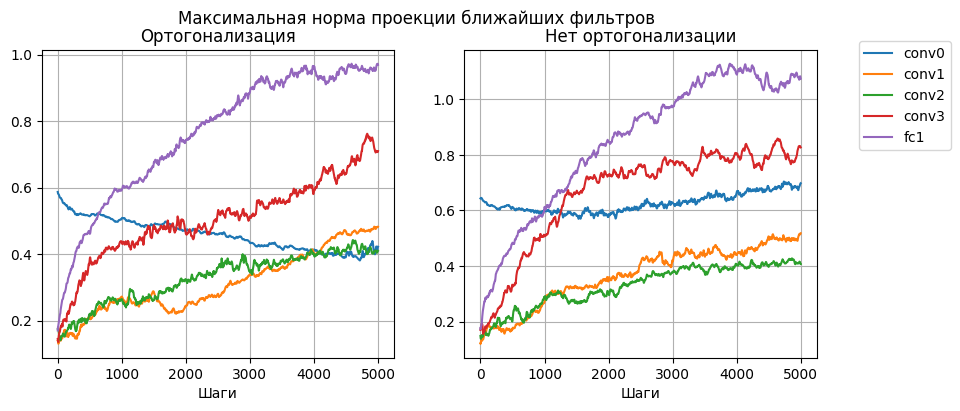

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for l_i, layer in enumerate(ortho_model.to_orthogonalized):

    ax[0].plot(max_projections[l_i], label=layer)
    ax[1].plot(max_projections_not_ortho[l_i], label=layer)

ax[1].legend(bbox_to_anchor=(1.1, 1.05))
fig.suptitle("Максимальная норма проекции ближайших фильтров")
ax[0].set_title("Ортогонализация")
ax[1].set_title("Нет ортогонализации")
ax[0].set_xlabel("Шаги")
ax[1].set_xlabel("Шаги")
ax[0].grid(True)
ax[1].grid(True)

In [18]:
quant_ortho_model = quantization(ortho_model, 21, 25, True)

testing: 100%|██████████| 100/100 [00:01<00:00, 55.20it/s]


epoch #1: accuracy:  65.510%, loss:  0.96690.  17.71667s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 58.21it/s]


epoch #2: accuracy:  65.800%, loss:  0.95592.  20.34691s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 57.79it/s]


...

epoch #13: accuracy:  66.040%, loss:  0.94959.  15.88625s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 60.55it/s]


epoch #14: accuracy:  66.050%, loss:  0.94953.  15.88276s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 59.77it/s]

epoch #15: accuracy:  66.050%, loss:  0.94948.  16.22859s per epoch
279.1963894367218 сек


In [19]:
quant_not_ortho_model = quantization(not_ortho_model, 21, 25, True)

testing: 100%|██████████| 100/100 [00:01<00:00, 57.87it/s]


epoch #1: accuracy:  65.090%, loss:  0.99477.  18.48548s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 56.32it/s]


epoch #2: accuracy:  65.390%, loss:  0.98624.  19.51329s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 59.40it/s]


...

epoch #13: accuracy:  65.990%, loss:  0.97179.  16.20981s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 57.14it/s]


epoch #14: accuracy:  65.990%, loss:  0.97177.  16.35678s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 61.08it/s]

epoch #15: accuracy:  65.970%, loss:  0.97175.  16.02367s per epoch
282.7211985588074 сек


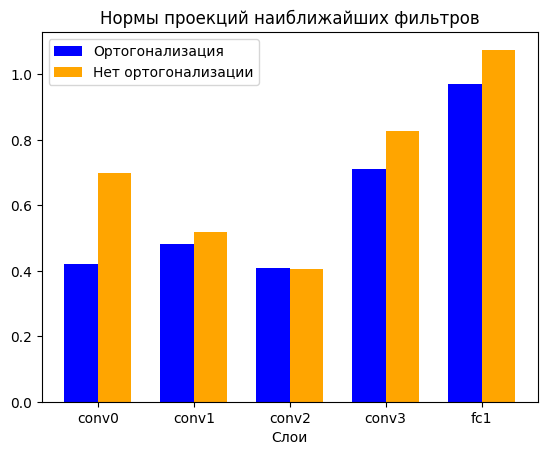

In [23]:
ortho_final_mp = [[] for _ in quant_ortho_model.to_orthogonalized]
not_ortho_final_mp = [[] for _ in quant_not_ortho_model.to_orthogonalized]

os = pseudo_ortho(_, _, ortho_final_mp)
nos = pseudo_ortho(_, _, not_ortho_final_mp)

os(quant_ortho_model)
nos(quant_not_ortho_model)

bar_width = 0.35
x = np.array([i for i in range(len(ortho_final_mp))])
plt.bar(x - bar_width/2, torch.tensor(ortho_final_mp).reshape(len(x)),
        width=bar_width, label='Ортогонализация', color='blue')
plt.bar(x + bar_width/2, torch.tensor(not_ortho_final_mp).reshape(len(x)), width=bar_width, label='Нет ортогонализации', color='orange')

# Adding labels, title, and legend
plt.xlabel('Слои')
plt.title('Нормы проекций наиближайших фильтров')
plt.xticks(x, labels=quant_ortho_model.to_orthogonalized)  # Custom x-axis labels
plt.legend()

### Матрица Пирсона

##### без регуляризации

In [9]:
from PearsonCorrelation import *

In [10]:
pm_model = CNN6()
device = torch.device("cpu")
device

device(type='cpu')

In [11]:
step_epochs = 10

lr_scale = 0.5
n_steps = 1

wort = 0.05

In [ ]:
pretrain_start = time()
optimizer = optim.AdamW(pm_model.parameters(), lr=2e-3, weight_decay=1e-5)

mean_corrs = []
corrs_l = [[] for _ in pm_model.to_orthogonalized]

pearson_corr = count_mean_filter_correlation_model(mean_corrs, corrs_l)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

train_stat_no, test_stat_no = train(pm_model, optimizer, train_loader, test_loader, loss,
                              n_epochs=step_epochs * n_steps, scheduler=scheduler,
                              device=device, use_tqdm=True, print_results=True, model_update=pearson_corr)
pretrain_end = time()
print(pretrain_end - pretrain_start, "сек.")

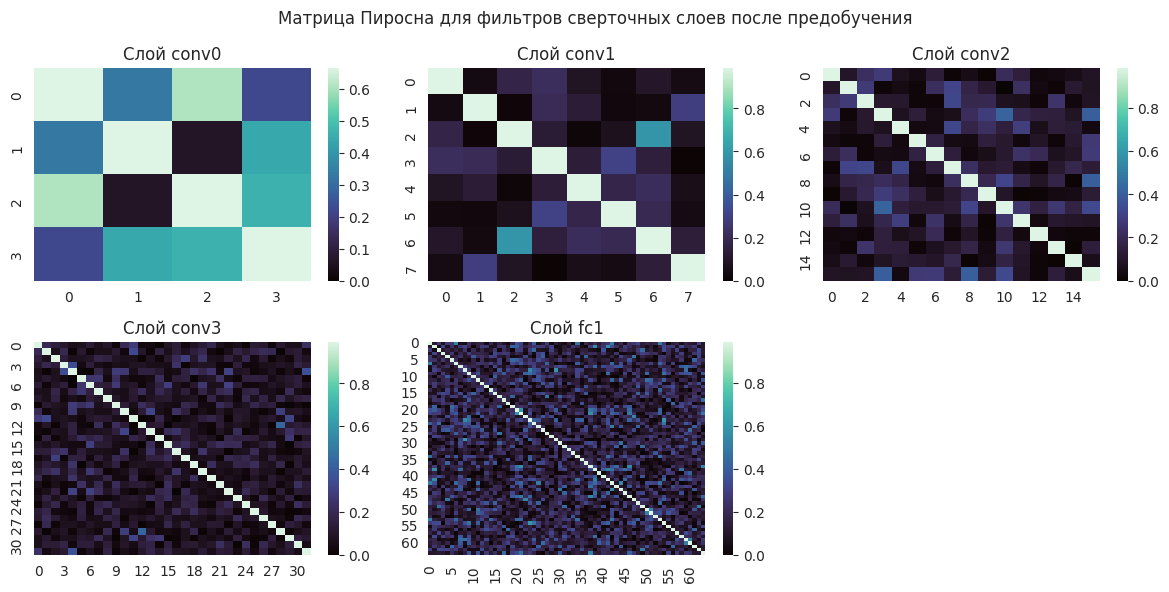

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 3, figsize=(12, 6))

for i, layer in enumerate(pm_model.to_orthogonalized):
    pm_layer = pearson_correlation_mat(pm_model.get_submodule(f"{layer}").get_weight())
    sns.heatmap(pm_layer.abs(), cmap="mako", vmin=0, ax=ax[i // 3][i % 3])
    ax[i // 3][i % 3].set_title(f"Слой {layer}")

fig.suptitle("Матрица Пиросна для фильтров сверточных слоев после предобучения")
fig.tight_layout()
fig.delaxes(ax[1][2])

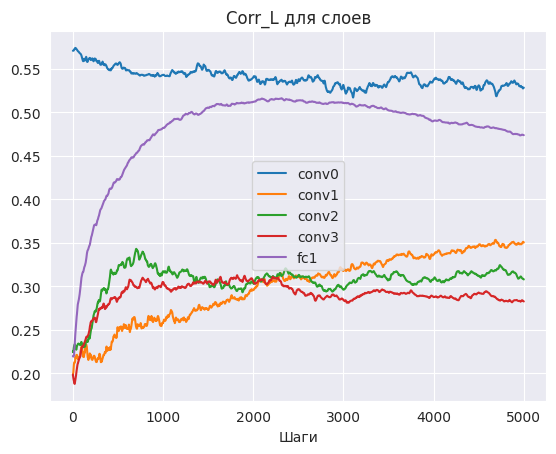

In [14]:
for i, layer_name in enumerate(pm_model.to_orthogonalized):
    plt.plot(corrs_l[i], label=layer_name)
plt.title("Corr_L для слоев")
plt.xlabel("Шаги")
plt.legend()
print()

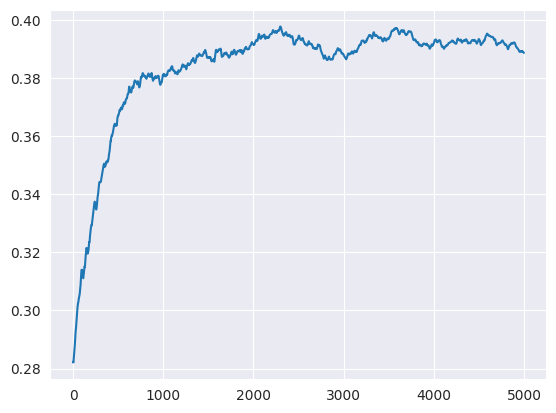

In [21]:
plt.plot(mean_corrs)

In [17]:
mean_corrs_quant = []
coors_l_quant = [[] for _ in pm_model.to_orthogonalized]

pearson_corr_quant = count_mean_filter_correlation_model(mean_corrs_quant, coors_l_quant)

quant_pm_model = quantization(pm_model, 21, 25, True, model_update=pearson_corr_quant)

testing: 100%|██████████| 100/100 [00:01<00:00, 59.65it/s]


epoch #1: accuracy:  66.640%, loss:  0.96323.  19.53425s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 60.09it/s]


epoch #2: accuracy:  65.830%, loss:  0.96874.  21.74328s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 60.42it/s]


...

epoch #13: accuracy:  66.530%, loss:  0.94488.  16.43661s per epoch


testing: 100%|██████████| 100/100 [00:04<00:00, 23.30it/s]


epoch #14: accuracy:  66.520%, loss:  0.94490.  31.88068s per epoch


testing: 100%|██████████| 100/100 [00:04<00:00, 23.58it/s]

epoch #15: accuracy:  66.540%, loss:  0.94489.  35.29089s per epoch
322.9695873260498 сек


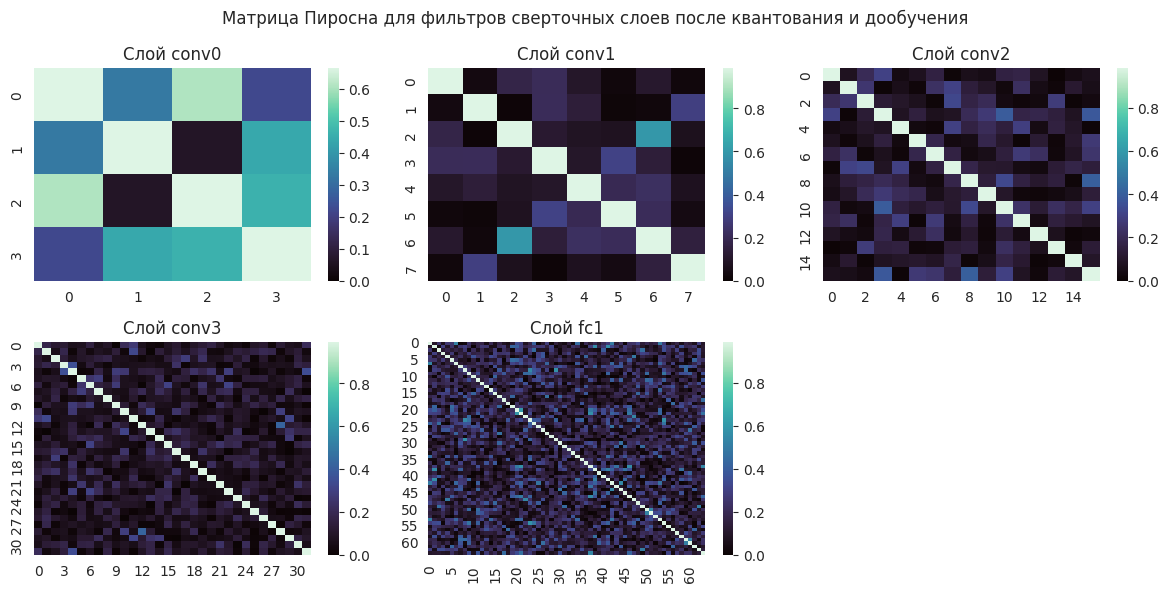

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 3, figsize=(12, 6))

for i, layer in enumerate(quant_pm_model.to_orthogonalized):
    pm_layer = pearson_correlation_mat(quant_pm_model.get_submodule(f"{layer}").get_weight())
    sns.heatmap(pm_layer.abs(), cmap="mako", vmin=0, ax=ax[i // 3][i % 3])
    ax[i // 3][i % 3].set_title(f"Слой {layer}")

fig.suptitle("Матрица Пиросна для фильтров сверточных слоев после квантования и дообучения")
fig.tight_layout()
fig.delaxes(ax[1][2])

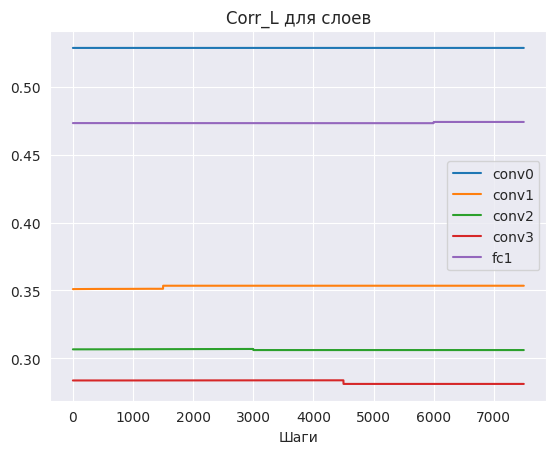

In [19]:
for i, layer_name in enumerate(quant_pm_model.to_orthogonalized):
    plt.plot(coors_l_quant[i], label=layer_name)
plt.title("Corr_L для слоев")
plt.xlabel("Шаги")
plt.legend()
print()

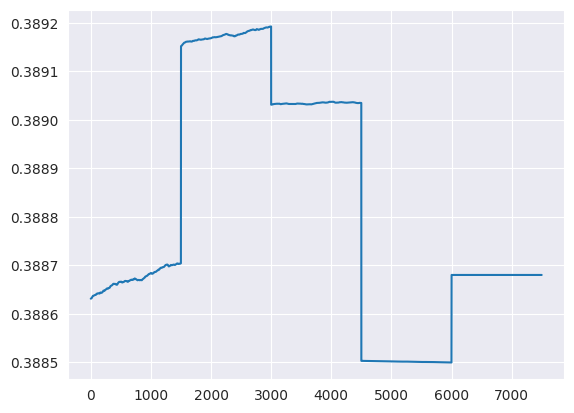

In [20]:
plt.plot(mean_corrs_quant)

##### Применяя регуляризацию

In [9]:
from PearsonCorrelation import *

In [10]:
reg_pm_model = CNN6()
device = torch.device("cpu")
device

device(type='cpu')

In [11]:
step_epochs = 10

lr_scale = 0.5
n_steps = 1

corr_reg = 5

In [12]:
pretrain_start = time()
optimizer = optim.AdamW(reg_pm_model.parameters(), lr=2e-3, weight_decay=1e-5)

mean_corrs = []
corrs_l = [[] for _ in reg_pm_model.to_orthogonalized]

pearson_corr_loss = correlation_loss(corr_reg, mean_corrs, corrs_l)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

train_stat_no, test_stat_no = train(reg_pm_model, optimizer, train_loader, test_loader, loss,
                              n_epochs=step_epochs * n_steps, scheduler=scheduler,
                              device=device, use_tqdm=True, print_results=True,
                              model_regularization=pearson_corr_loss)
pretrain_end = time()
print(pretrain_end - pretrain_start, "сек.")

testing: 100%|██████████| 100/100 [00:01<00:00, 66.10it/s]


epoch #1: accuracy:  45.390%, loss:  1.51867.  22.22686s per epoch


testing: 100%|██████████| 100/100 [00:02<00:00, 47.72it/s]


epoch #2: accuracy:  51.420%, loss:  1.35745.  26.37932s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 66.49it/s]


...

epoch #8: accuracy:  60.240%, loss:  1.12261.  24.25285s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 64.30it/s]


epoch #9: accuracy:  62.440%, loss:  1.05938.  24.04636s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 65.07it/s]

epoch #10: accuracy:  62.030%, loss:  1.07767.  23.80921s per epoch
246.03496098518372 сек.


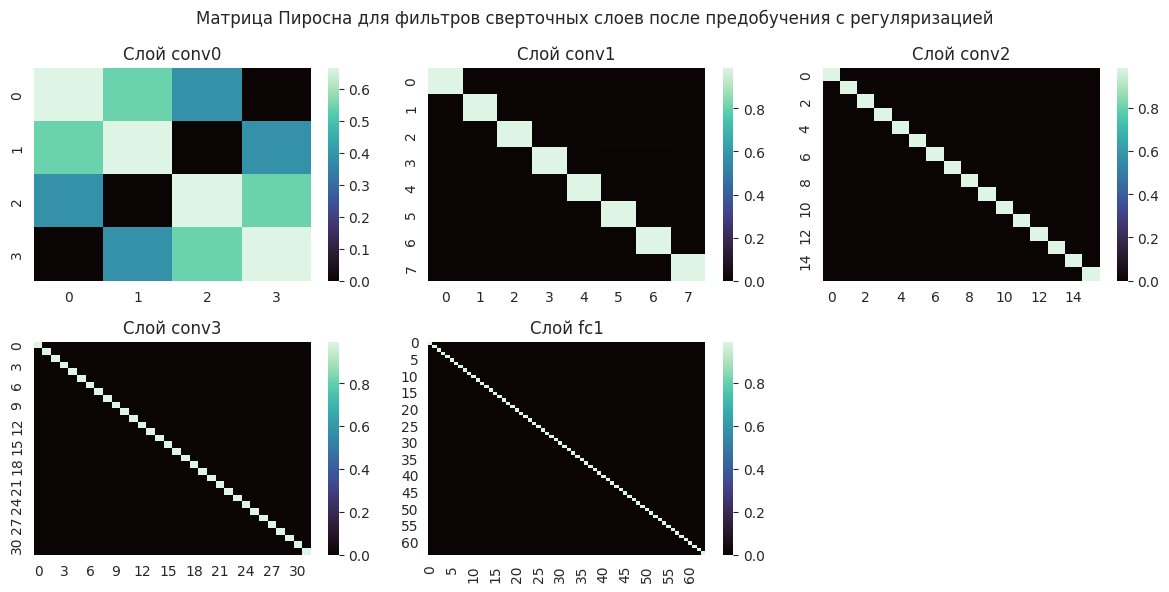

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 3, figsize=(12, 6))

with torch.no_grad():
    for i, layer in enumerate(reg_pm_model.to_orthogonalized):
        pm_layer = pearson_correlation_mat(reg_pm_model.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_layer.abs(), cmap="mako", vmin=0, ax=ax[i // 3][i % 3])
        ax[i // 3][i % 3].set_title(f"Слой {layer}")

fig.suptitle("Матрица Пиросна для фильтров сверточных слоев после предобучения с регуляризацией")
fig.tight_layout()
fig.delaxes(ax[1][2])

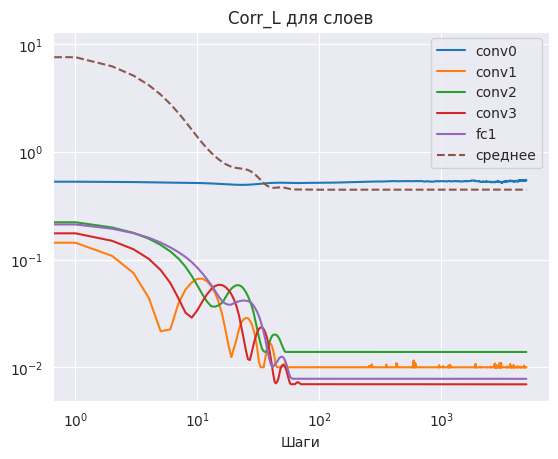

In [35]:
with torch.no_grad():
    for i, layer_name in enumerate(reg_pm_model.to_orthogonalized):
        # if i != 0:
        plt.plot(corrs_l[i], label=layer_name)
    plt.plot(mean_corrs, label="среднее", linestyle="--")

plt.title("Corr_L для слоев")
plt.xlabel("Шаги")
plt.yscale("log")
plt.xscale("log")
plt.legend()
print()

In [36]:
mean_corrs_quant = []
coors_l_quant = [[] for _ in reg_pm_model.to_orthogonalized]

pearson_corr_quant = count_mean_filter_correlation_model(mean_corrs_quant, coors_l_quant)

quant_reg_pm_model = quantization(reg_pm_model, 21, 25, True, model_update=pearson_corr_quant)

testing: 100%|██████████| 100/100 [00:01<00:00, 61.08it/s]


epoch #1: accuracy:  63.980%, loss:  1.02119.  18.51766s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 58.43it/s]


epoch #2: accuracy:  63.500%, loss:  1.03149.  20.11464s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 57.54it/s]


...

epoch #13: accuracy:  64.230%, loss:  1.01280.  16.48943s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 56.80it/s]


epoch #14: accuracy:  64.220%, loss:  1.01280.  16.93362s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 59.87it/s]

epoch #15: accuracy:  64.200%, loss:  1.01279.  16.60811s per epoch
300.15820240974426 сек


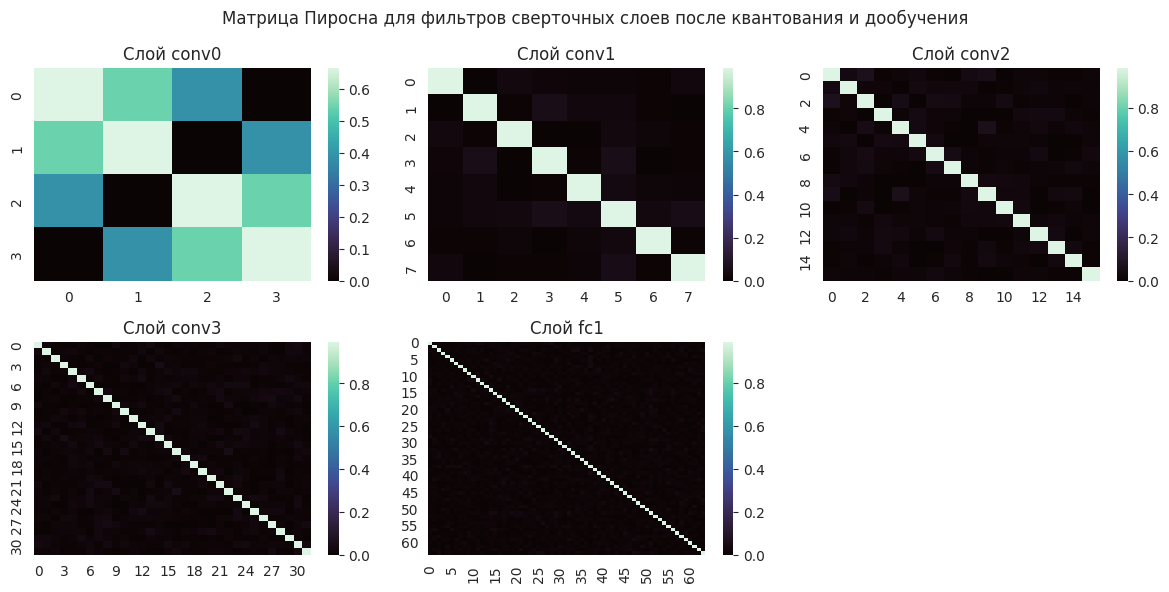

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 3, figsize=(12, 6))

with torch.no_grad():
    for i, layer in enumerate(quant_pm_model.to_orthogonalized):
        pm_layer = pearson_correlation_mat(quant_pm_model.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_layer.abs(), cmap="mako", vmin=0, ax=ax[i // 3][i % 3])
        ax[i // 3][i % 3].set_title(f"Слой {layer}")

fig.suptitle("Матрица Пиросна для фильтров сверточных слоев после квантования и дообучения")
fig.tight_layout()
fig.delaxes(ax[1][2])

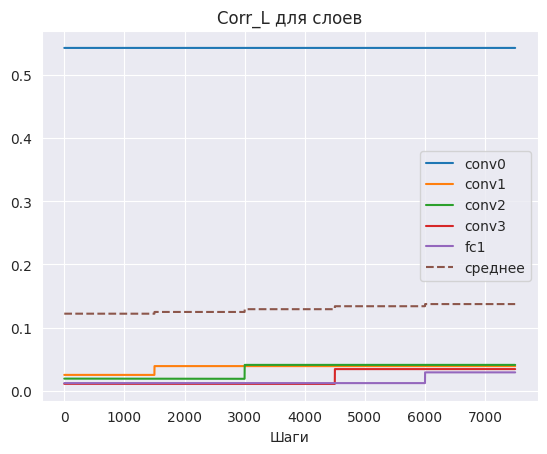

In [39]:
with torch.no_grad():
    for i, layer_name in enumerate(quant_pm_model.to_orthogonalized):
        # if i != 0:
        plt.plot(coors_l_quant[i], label=layer_name)
    plt.plot(mean_corrs_quant, label="среднее", linestyle="--")

plt.title("Corr_L для слоев")
plt.xlabel("Шаги")
# plt.yscale("log")
# plt.xscale("log")
plt.legend()
print()

##### Другие коэффициенты регуляризации

In [9]:
from PearsonCorrelation import *

In [10]:
reg_model = CNN6()
device = torch.device("cpu")

In [11]:
step_epochs = 10

lr_scale = 0.5
n_steps = 1

corr_reg = 0.5

In [12]:
optimizer = optim.AdamW(reg_model.parameters(), lr=2e-3, weight_decay=1e-5)

mean_corrs = []
corrs_l = [[] for _ in reg_model.to_orthogonalized]

pearson_corr_loss = correlation_loss(corr_reg, mean_corrs, corrs_l)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

train_stat_no, test_stat_no = train(reg_model, optimizer, train_loader, test_loader, loss,
                              n_epochs=step_epochs * n_steps, scheduler=scheduler,
                              device=device, use_tqdm=True, print_results=True,
                              model_regularization=pearson_corr_loss)
pretrain_end = time()

testing: 100%|██████████| 100/100 [00:01<00:00, 63.88it/s]


epoch #1: accuracy:  45.860%, loss:  1.47356.  21.98798s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 65.18it/s]


epoch #2: accuracy:  52.630%, loss:  1.29257.  23.63269s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 66.65it/s]


...

epoch #8: accuracy:  61.950%, loss:  1.07706.  24.10935s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 64.65it/s]


epoch #9: accuracy:  61.530%, loss:  1.07658.  23.52097s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 64.18it/s]

epoch #10: accuracy:  64.280%, loss:  1.00790.  23.42824s per epoch


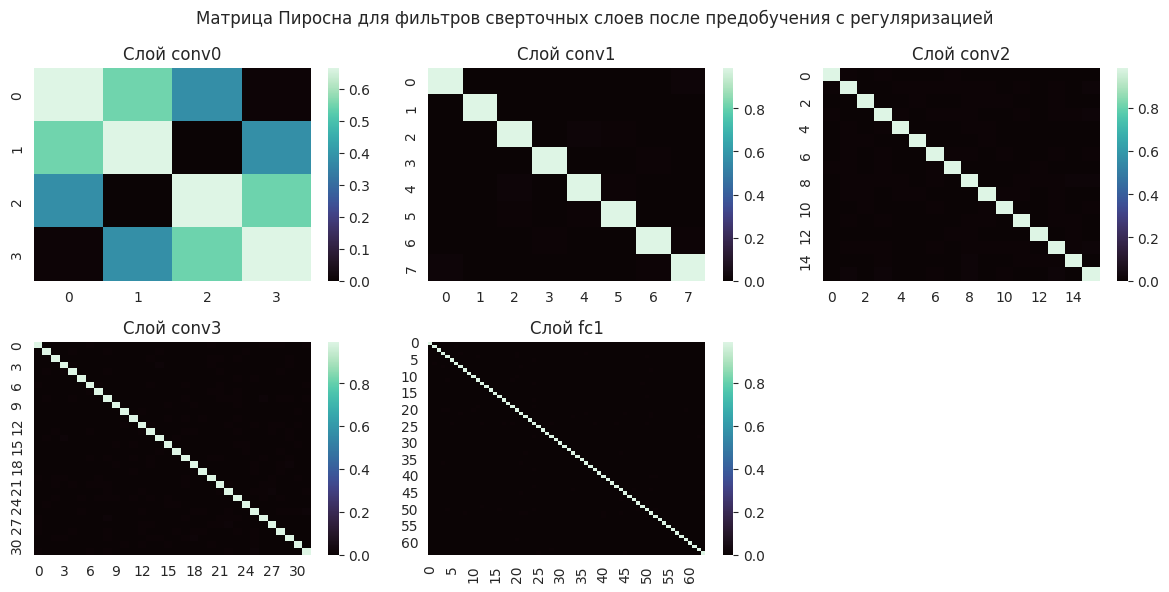

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 3, figsize=(12, 6))

with torch.no_grad():
    for i, layer in enumerate(reg_model.to_orthogonalized):
        pm_layer = pearson_correlation_mat(reg_model.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_layer.abs(), cmap="mako", vmin=0, ax=ax[i // 3][i % 3])
        ax[i // 3][i % 3].set_title(f"Слой {layer}")

fig.suptitle("Матрица Пиросна для фильтров сверточных слоев после предобучения с регуляризацией")
fig.tight_layout()
fig.delaxes(ax[1][2])

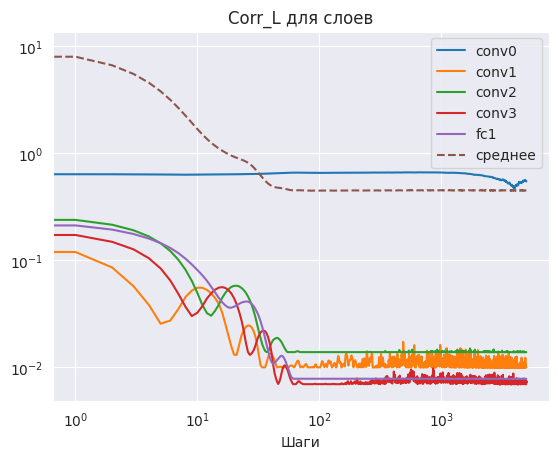

In [21]:
with torch.no_grad():
    for i, layer_name in enumerate(reg_model.to_orthogonalized):
        # if i != 0:
        plt.plot(corrs_l[i], label=layer_name)
    plt.plot(mean_corrs, label="среднее", linestyle="--")

plt.title("Corr_L для слоев")
plt.xlabel("Шаги")
plt.yscale("log")
plt.xscale("log")

plt.legend()
print()

##### Сравнение матрицы Пирсона с и без ортогонализации

In [12]:
ortho_model = CNN6()
device = torch.device("cpu")

step_epochs = 10

lr_scale = 0.5
n_steps = 1

wort = 0.05

In [13]:
from Orthogonalization import ortho_step

In [14]:
pretrain_start = time()
optimizer = optim.AdamW(ortho_model.parameters(), lr=2e-3, weight_decay=1e-5)

mean_corrs = []
corrs_l = [[] for _ in pm_model.to_orthogonalized]
pearson_corr = count_mean_filter_correlation_model(mean_corrs, corrs_l)

ortho_update = ortho_step(wort, optimizer)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

train_stat, test_stat = train(ortho_model, optimizer, train_loader, test_loader, loss,
                              n_epochs=step_epochs * n_steps, scheduler=scheduler,
                              device=device, use_tqdm=True, print_results=True,
                              model_update=[ortho_update, pearson_corr])
pretrain_end = time()
print(pretrain_end - pretrain_start, "сек.")

testing: 100%|██████████| 100/100 [00:01<00:00, 62.26it/s]


epoch #1: accuracy:  51.370%, loss:  1.35096.  60.04376s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 68.73it/s]


epoch #2: accuracy:  56.060%, loss:  1.22334.  62.48049s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 68.88it/s]


...

epoch #8: accuracy:  63.500%, loss:  1.02607.  62.60518s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 66.55it/s]


epoch #9: accuracy:  64.050%, loss:  1.01842.  62.62299s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 67.51it/s]

epoch #10: accuracy:  65.480%, loss:  0.98829.  62.60416s per epoch
623.1442530155182 сек.


In [16]:
from PearsonCorrelation import *

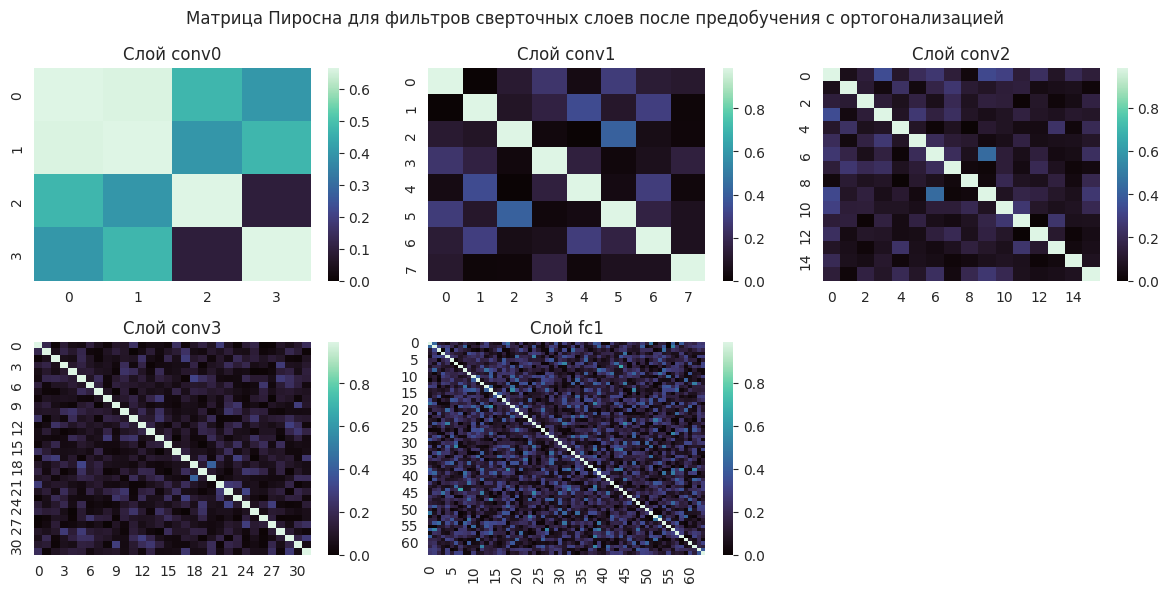

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 3, figsize=(12, 6))

with torch.no_grad():
    for i, layer in enumerate(ortho_model.to_orthogonalized):
        pm_layer = pearson_correlation_mat(ortho_model.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_layer.abs(), cmap="mako", vmin=0, ax=ax[i // 3][i % 3])
        ax[i // 3][i % 3].set_title(f"Слой {layer}")

fig.suptitle("Матрица Пиросна для фильтров сверточных слоев после предобучения c ортогонализацией")
fig.tight_layout()
fig.delaxes(ax[1][2])

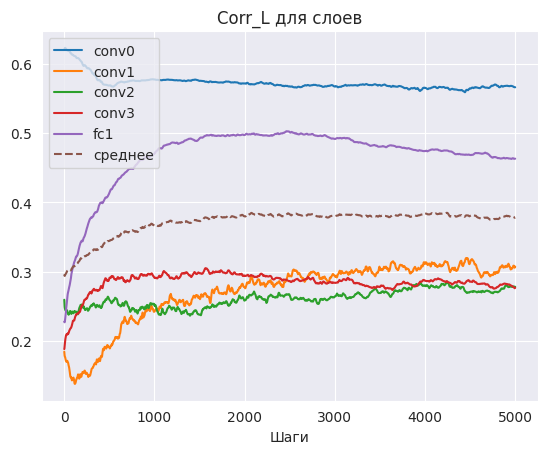

In [17]:
for i, layer_name in enumerate(ortho_model.to_orthogonalized):
    plt.plot(corrs_l[i], label=layer_name)
plt.plot(mean_corrs, label="среднее", linestyle="--")
plt.title("Corr_L для слоев")
plt.xlabel("Шаги")
plt.legend()
print()

In [18]:
not_ortho_model = CNN6()

In [ ]:
pretrain_start = time()
optimizer = optim.AdamW(not_ortho_model.parameters(), lr=2e-3, weight_decay=1e-5)

mean_corrs = []
corrs_l = [[] for _ in not_ortho_model.to_orthogonalized]
pearson_corr = count_mean_filter_correlation_model(mean_corrs, corrs_l)

# ortho_update = ortho_step(wort, optimizer)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

train_stat, test_stat = train(not_ortho_model, optimizer, train_loader, test_loader, loss,
                              n_epochs=step_epochs * n_steps, scheduler=scheduler,
                              device=device, use_tqdm=True, print_results=True,
                              model_update=pearson_corr)
pretrain_end = time()
print(pretrain_end - pretrain_start, "сек.")

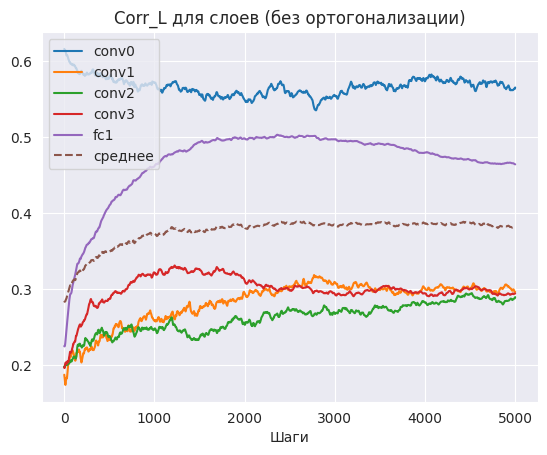

In [20]:
for i, layer_name in enumerate(not_ortho_model.to_orthogonalized):
    plt.plot(corrs_l[i], label=layer_name)
plt.plot(mean_corrs, label="среднее", linestyle="--")
plt.title("Corr_L для слоев (без ортогонализации)")
plt.xlabel("Шаги")
plt.legend()
print()

### Ковариация карт признаков

In [9]:
from PearsonCorrelation import *
from FeaturesCovariance import *

In [10]:
model = CNN6()
device = torch.device("cpu")
device

device(type='cpu')

In [11]:
step_epochs = 10

lr_scale = 0.5
n_steps = 1

feat_cov_reg = 2

In [12]:
pretrain_start = time()
optimizer = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-5)

mean_corrs = []
corrs_l = [[] for _ in model.to_orthogonalized]
pearson_corr = count_mean_filter_correlation_model(mean_corrs, corrs_l)

fc_reg = feat_cov_loss(feat_cov_reg, [1])

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

train_stat, test_stat = train(model, optimizer, train_loader, test_loader, loss,
                              n_epochs=step_epochs * n_steps, scheduler=scheduler,
                              device=device, use_tqdm=True, print_results=True,
                              model_regularization=fc_reg,
                              model_update=pearson_corr)
pretrain_end = time()
print(pretrain_end - pretrain_start, "сек.")

testing: 100%|██████████| 100/100 [00:02<00:00, 44.11it/s]


epoch #1: accuracy:  50.540%, loss:  1.39619.  29.22882s per epoch


testing: 100%|██████████| 100/100 [00:02<00:00, 45.54it/s]


epoch #2: accuracy:  54.380%, loss:  1.29474.  33.01649s per epoch


testing: 100%|██████████| 100/100 [00:02<00:00, 45.27it/s]


...

epoch #8: accuracy:  62.040%, loss:  1.07915.  40.69154s per epoch


testing: 100%|██████████| 100/100 [00:02<00:00, 37.64it/s]


epoch #9: accuracy:  63.970%, loss:  1.01958.  38.80354s per epoch


testing: 100%|██████████| 100/100 [00:02<00:00, 40.33it/s]

epoch #10: accuracy:  65.720%, loss:  0.97588.  38.40168s per epoch
362.1233069896698 сек.


Text(0.5, 1.0, 'Матрица Пирсона для слоя conv2 после предобучения с регуляризацией по ковариации признаков')

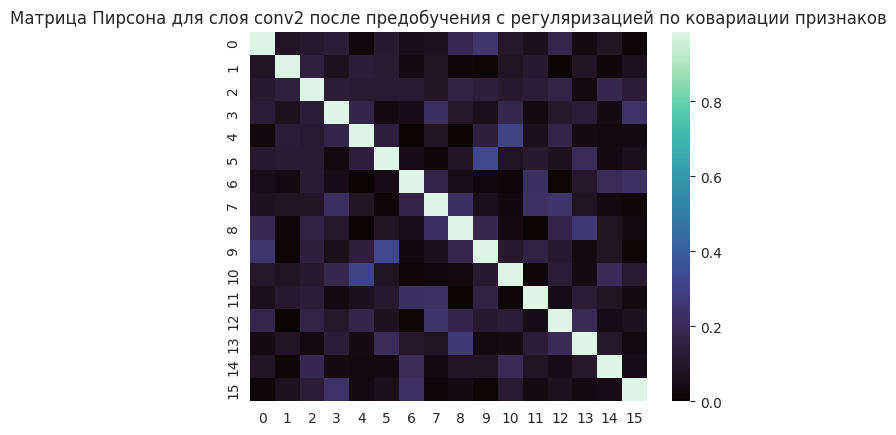

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# fig, ax = plt.subplots(2, 3, figsize=(12, 6))
with torch.no_grad():
    pm = pearson_correlation_mat(model.get_submodule("conv2").get_weight())
    sns.heatmap(pm.abs(), cmap="mako", vmin=0)
plt.title("Матрица Пирсона для слоя conv2 после предобучения с регуляризацией по ковариации признаков")
#
# with torch.no_grad():
#     for i, layer in enumerate(model.to_orthogonalized):
#         pm_layer = pearson_correlation_mat(model.get_submodule(f"{layer}").get_weight())
#         sns.heatmap(pm_layer.abs(), cmap="mako", vmin=0, ax=ax[i // 3][i % 3])
#         ax[i // 3][i % 3].set_title(f"Слой {layer}")
#
# fig.suptitle("Матрица Пиросна для фильтров сверточных слоев после предобучения с регуляризацией по ковариации признаков")
# fig.tight_layout()
# fig.delaxes(ax[1][2])

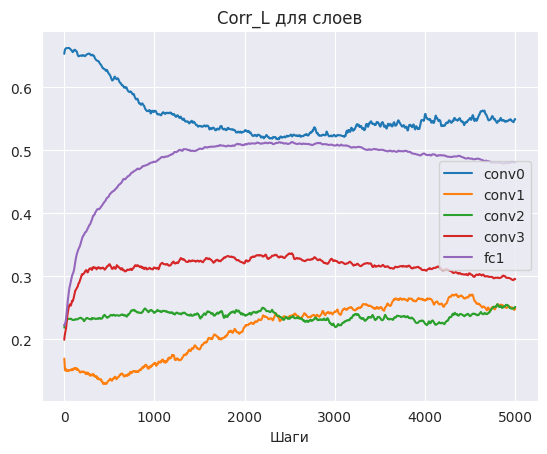

In [14]:
for i, layer_name in enumerate(model.to_orthogonalized):
    plt.plot(corrs_l[i], label=layer_name)
plt.title("Corr_L для слоев")
plt.xlabel("Шаги")
plt.legend()
print()